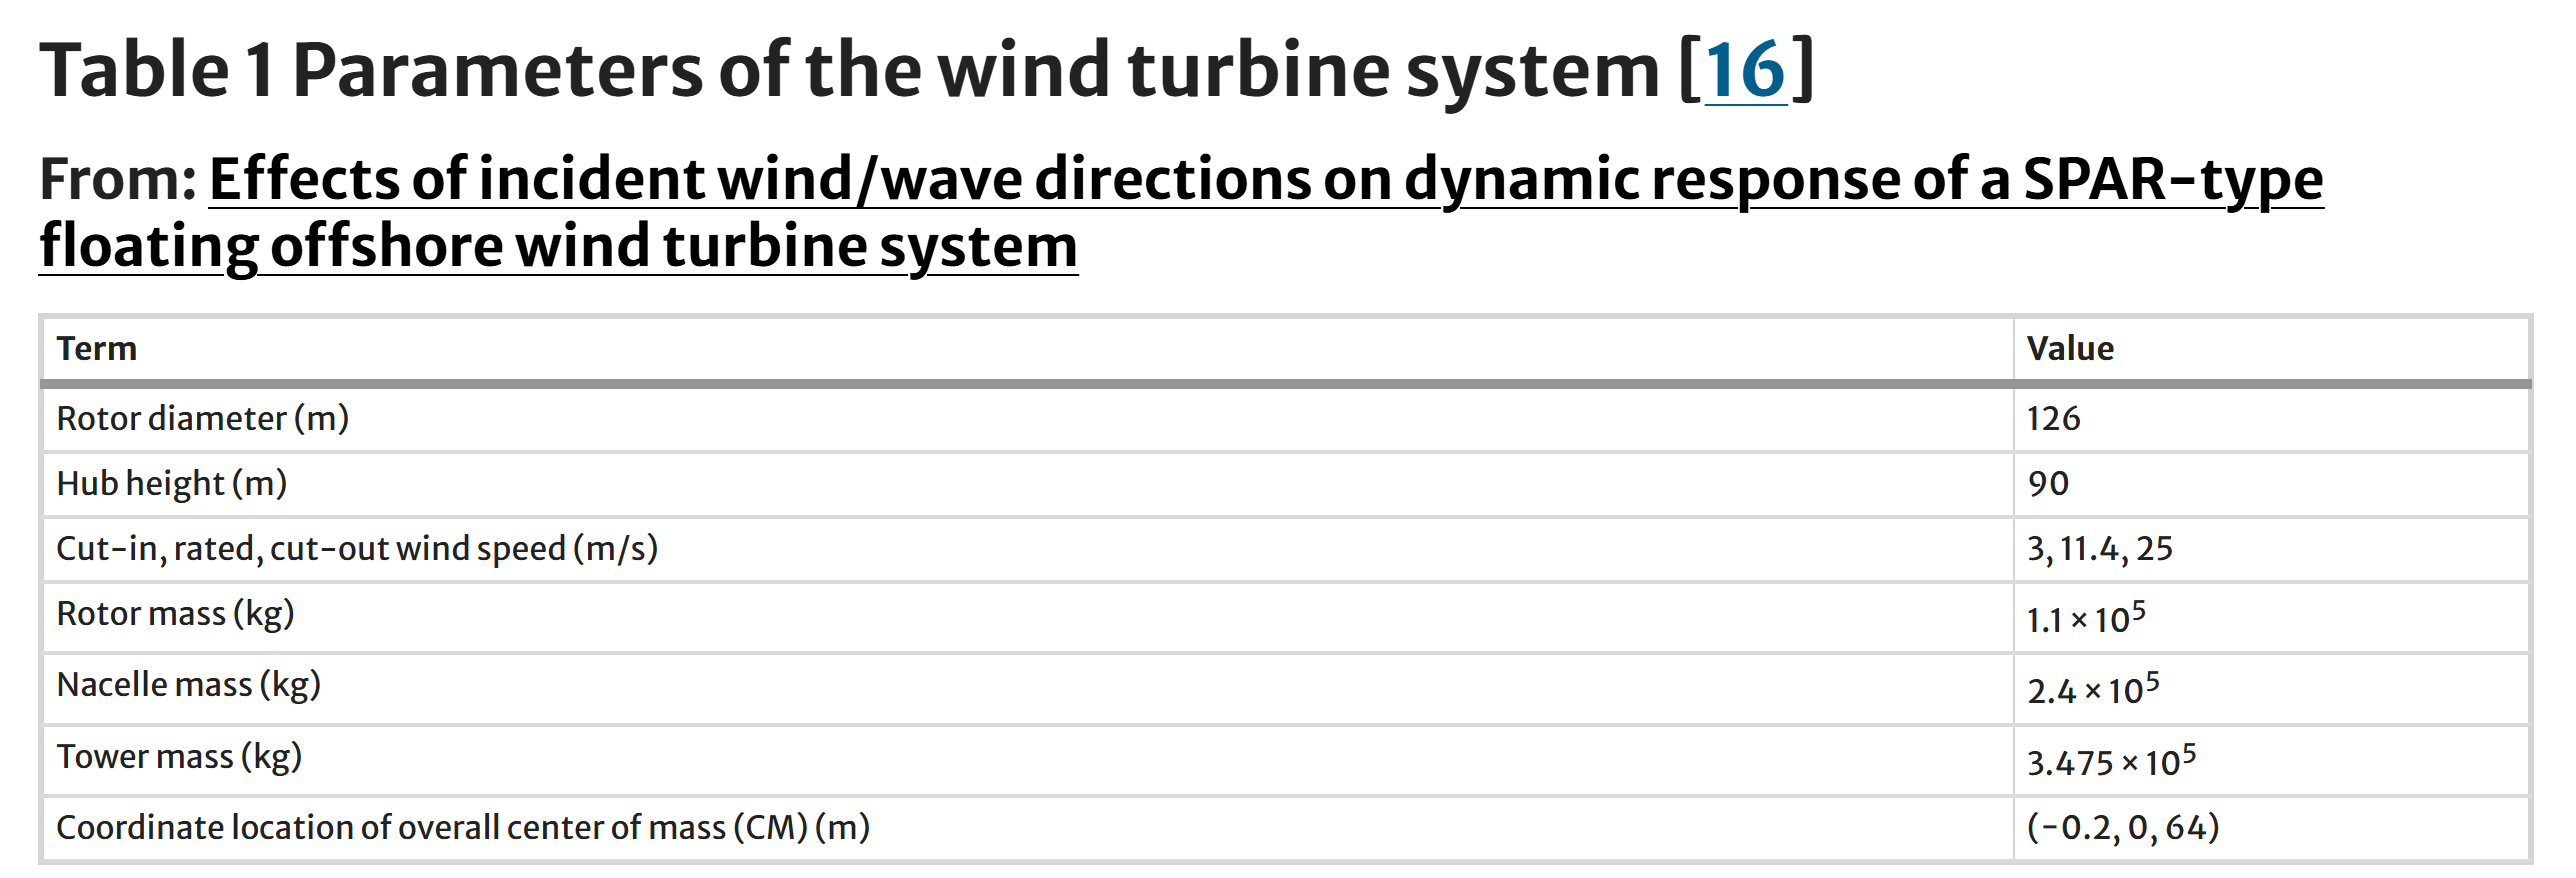

Mean wind speed at 100 m: 7.27 m/s
Mean wind speed at hub height (90 m): 7.17 m/s


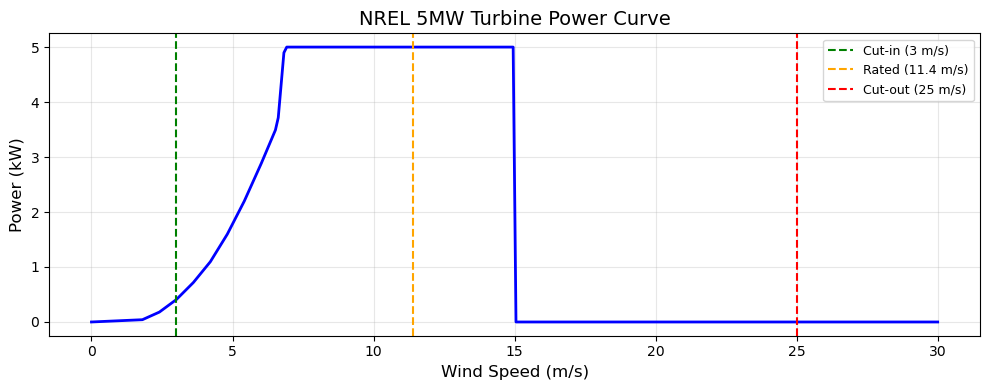

In [10]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


data_dir= r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\data aquisition\data'
eva_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\EVA'
power_production_dir = r'C:\Users\Carolina\Documents\MSc Civil Engineering\Marine renewables\marine renewables\Marine-renewables\power_production'
#load wind data

df_wind = pd.read_csv(f"{data_dir}/wind_data_sines_2010_2020.csv", index_col=0, parse_dates=True)

#correction hub height
alpha = 0.14
df_wind['U_hub'] = df_wind['wind_speed_100m_ms'] * (90 / 100)**alpha

print(f"Mean wind speed at 100 m: {df_wind['wind_speed_100m_ms'].mean():.2f} m/s")
print(f"Mean wind speed at hub height (90 m): {df_wind['U_hub'].mean():.2f} m/s")

# ── NREL 5MW power curve ───────────────────────────────────────────
pc_wind = np.array([0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 11.4,
                    12, 13, 14, 15, 16, 17, 18, 19, 20,
                    21, 22, 23, 24, 25, 25.01, 50])
pc_power = np.array([0, 40, 177, 403, 710, 1084, 1581, 2178,
                     2860, 3586, 5000, 5000, 5000, 5000, 5000,
                     5000, 5000, 5000, 5000, 5000, 5000, 5000,
                     5000, 5000, 5000, 0, 0])  # kW

power_curve = np.interp(np.linspace(0, 50, 300), pc_wind, pc_power)

#plot power curve
u_range = np.linspace(0, 30,300)
plt.figure(figsize=(10, 4))
plt.plot(u_range, power_curve/1000, 'b-', linewidth = 2)
plt.axvline(3, color='green', linestyle='--', label='Cut-in (3 m/s)')
plt.axvline(11.4, color='orange', linestyle='--', label='Rated (11.4 m/s)')
plt.axvline(25, color='red', linestyle='--', label='Cut-out (25 m/s)')
plt.xlabel('Wind Speed (m/s)', fontsize=12)
plt.ylabel('Power (kW)', fontsize=12)
plt.title('NREL 5MW Turbine Power Curve', fontsize=14)
plt.legend(fontsize=9)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig(f"{power_production_dir}/wind_power_curve.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
df_wind['power_kW'] = np.interp(df_wind['U_hub'], pc_wind, pc_power)

print(f"Mean power production at hub height: {df_wind['power_kW'].mean():.2f} kW")
print(f"Max power production at hub height: {df_wind['power_kW'].max():.2f} kW")
print(f"% time at rated:     {(df_wind['power_kW'] >= 4999).mean()*100:.1f}%")
print(f"% time cut-in to cut-out: {((df_wind['U_hub'] >= 3) & (df_wind['U_hub'] <= 25)).mean()*100:.1f}%")
print(f"% time below cut-in: {(df_wind['U_hub'] < 3).mean()*100:.1f}%")
print(f"% time above cut-out:{(df_wind['U_hub'] > 25).mean()*100:.1f}%")



Mean power production at hub height: 1622.52 kW
Max power production at hub height: 5000.00 kW
% time at rated:     11.8%
% time cut-in to cut-out: 89.2%
% time below cut-in: 10.8%
% time above cut-out:0.0%


In [ ]:
#annual energy production 

dt_hours = 3
AEP_kWh = df_wind['power_kW'].sum() * dt_hours
AEP_annual_MWh = AEP_kWh / 1000 / 365  ##WHYYY 
AEP_annual_GWh = AEP_annual_MWh / 1000

print(f"Annual energy production:")
print(f"{AEP_kWh:.2f} kWh")
print(f"{AEP_annual_MWh:.2f} MWh")



Annual energy production:
142249336.63 kWh
389.72 MWh


In [15]:
#capacity factor 
P_rated = 5000 # kW
T_hours = 365 * 24
CF = AEP_annual_MWh / (P_rated * T_hours / 1000)  

print("Capacity factor: {:.2f}%".format(CF * 100))

Capacity factor: 0.89%


SOMETHING IS WRONG, IT SHOULD BE AROUND 40-55% !!!!!!!!!!!

AEP variability:
Mean annual AEP: 14224.93 MWh
Min annual AEP: 12601.95 MWh
Max annual AEP: 15499.06 MWh
Standard deviation: 983.48 MWh


C:\Users\Carolina\AppData\Local\Temp\ipykernel_4556\512907039.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


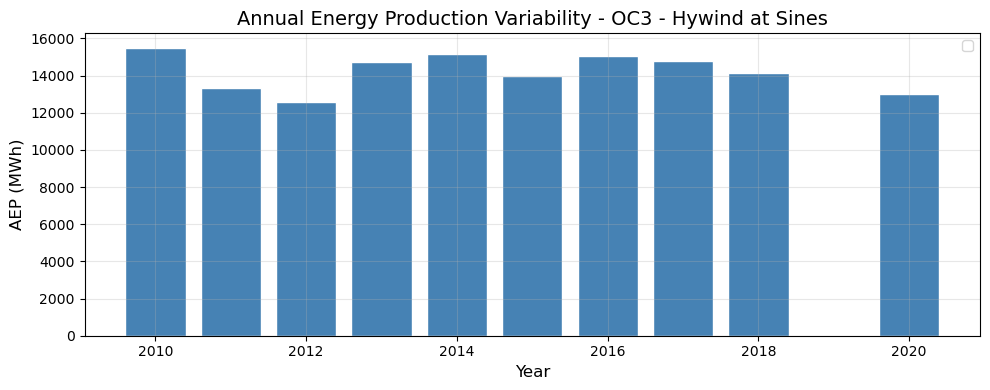

In [19]:
# annual variability 

df_wind['year']= df_wind.index.year
annual_aep = df_wind.groupby('year')['power_kW'].sum() * dt_hours / 1000  

print("AEP variability:")
print(f"Mean annual AEP: {annual_aep.mean():.2f} MWh")
print(f"Min annual AEP: {annual_aep.min():.2f} MWh")
print(f"Max annual AEP: {annual_aep.max():.2f} MWh")
print(f"Standard deviation: {annual_aep.std():.2f} MWh")

plt.figure(figsize=(10, 4))
plt.bar(annual_aep.index, annual_aep.values, color='steelblue', edgecolor='white')
plt.xlabel('Year', fontsize=12)
plt.ylabel('AEP (MWh)', fontsize=12)
plt.title('Annual Energy Production Variability - OC3 - Hywind at Sines', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{power_production_dir}/annual_aep_variability.png", dpi=300, bbox_inches='tight')
plt.show()